# Normalize, select, aggregate

Plates differ in imaging day, reagent lot and microscope state, and a CellProfiler run gives a few thousand
features, most of them redundant. This page puts every plate on the scale of its own controls, aggregates
cells to wells, and reduces the features to the informative ones.

The data is a synthetic plate that records what was injected into it, so each step can be checked.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import mantispy as mt

cells = mt.ds.synthetic_plate(
    n_plates=2,
    n_wells=96,
    n_cells=30,
    n_features=60,
    n_correlated_pairs=8,
    n_constant_features=4,
    effect_size=2.0,
    seed=0,
)
cells

AnnData object with n_obs × n_vars = 5760 × 68
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_Row', 'Metadata_Col', 'Metadata_Perturbation', 'Metadata_Control', 'Metadata_Batch', 'Metadata_ImageNumber', 'Metadata_CellCount'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

## Normalization

Plates differ in imaging day, reagent lot and microscope state. The standard fix is to express
every cell relative to the negative controls on its own plate, which is what
`reference="negcon"` together with `by="Metadata_Plate"` does.

The default method, `mad_robustize`, subtracts the control median and divides by a robust
spread, so a few extreme cells do not set the scale.

In [2]:
mt.pp.normalize(cells, method="mad_robustize", by="Metadata_Plate", reference="negcon", keep_raw=True)

controls = cells[cells.obs["Metadata_Control"]]
np.round(np.nanmedian(np.asarray(controls.X), axis=0)[:5], 6)

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_31392/3133004889.py:1: UserWarning: 4 of 68 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(cells, method="mad_robustize", by="Metadata_Plate", reference="negcon", keep_raw=True)


array([0., 0., 0., 0., 0.], dtype=float32)

The controls now sit at zero on every plate by construction. `keep_raw=True` kept the
original values in `layers["raw"]` for the before-and-after plot. It is off by default
because the extra layer doubles memory and the original is already on disk.

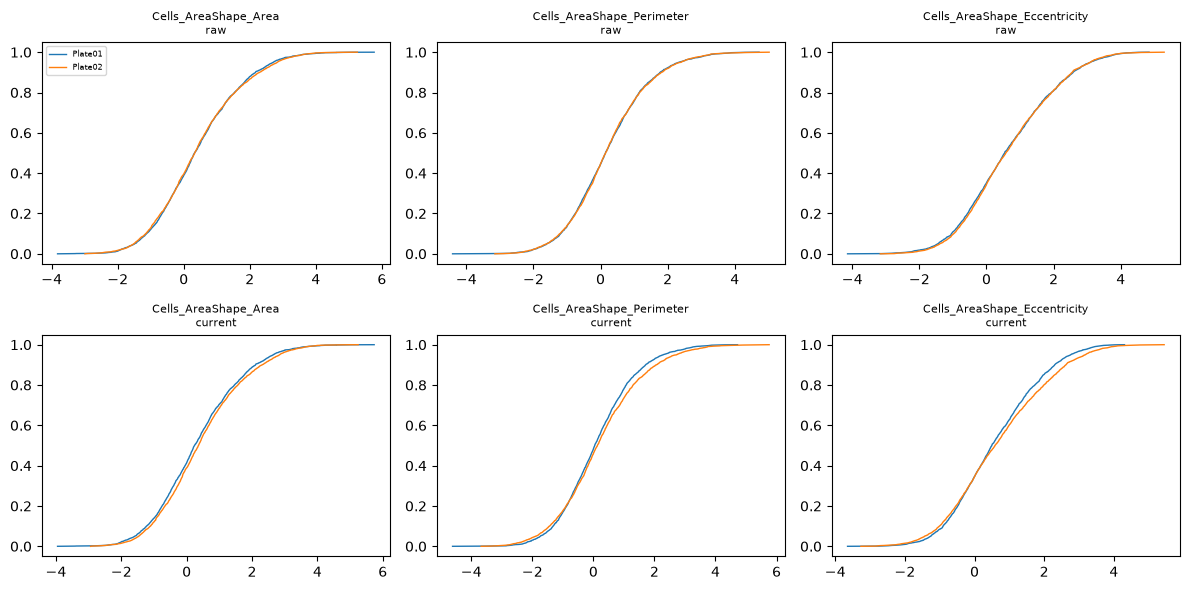

In [3]:
mt.pl.feature_distributions(cells, features=list(cells.var_names[:3]))
plt.show()

### Features normalization cannot scale

`normalize` warned and flagged four features in `var["degenerate_scale"]`. These are the constant features the
generator injected. They have no spread among the control cells, so `mad_robustize` divides them by
`epsilon = 1e-18` instead of by zero, as pycytominer {cite:p}`Serrano_2025` does. A feature that is constant
everywhere comes back as zeros; one that varies elsewhere on the plate comes back multiplied by up to 1e18.

In [4]:
{"flagged degenerate_scale": int(cells.var["degenerate_scale"].sum())}

{'flagged degenerate_scale': 4}

A variance threshold would remove these, but not a feature that varies across the plate and is constant among
the few control wells: it measures variance across all wells, keeps that feature, and the feature then
dominates every distance computed afterwards. The flag catches both. {func}`~mantispy.pp.feature_select` drops
flagged features first by default and judges the rest without them. Anything that reads the object before
selection needs them gone by hand:

```python
adata = adata[:, ~adata.var["degenerate_scale"].to_numpy()].copy()
```

## Aggregating to wells

Each well's profile is the median across its cells. The median is used instead of the mean so
that a few extreme cells do not move the profile.

In [5]:
wells = mt.tl.aggregate(cells, by=("Metadata_Plate", "Metadata_Well"), func="median")
wells

AnnData object with n_obs × n_vars = 192 × 68
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_CellCount', 'Metadata_Row', 'Metadata_Col', 'Metadata_Perturbation', 'Metadata_Control', 'Metadata_Batch', 'Metadata_ImageNumber'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'degenerate_scale'
    uns: 'mantispy'
    layers: None (.X)

The result records its provenance and keeps every metadata column that is constant within a
well. Columns that vary within a well, such as a per-cell measurement, are dropped because
they have no single value per well.

In [6]:
wells.uns["mantispy"]["aggregated_from"]

{'by': ['Metadata_Plate', 'Metadata_Well'],
 'func': 'median',
 'n_obs': 5760,
 'min_cells': 10}

`Metadata_CellCount` is added as well. Cell count is a common confounder, and
`mt.pp.regress_out` can remove its influence later.

## Feature selection

Most of a CellProfiler run's features are redundant. `AreaShape_Area` and `AreaShape_Perimeter` carry much the
same information, and so does a texture feature at scale 3 and the same texture at scale 5. Others are
constant, or blow up because they are ratios with a near-zero denominator.

mantispy reproduces pycytominer's operations {cite:p}`Serrano_2025`, verified feature by feature, because
published pipelines depend on their precise behavior.

The generator injected eight near-duplicate feature pairs and four constant features, so we can check that
selection removes them. `n_correlated_pairs=8` adds a partner for eight of the features, so the object has 68
columns instead of the 60 requested, and every count below is out of 68.

### Before

The correlation heatmap is ordered by feature group, with a line at each group boundary. The dark cells off the
diagonal are the injected near-duplicate pairs, and the pale band is the constant features.

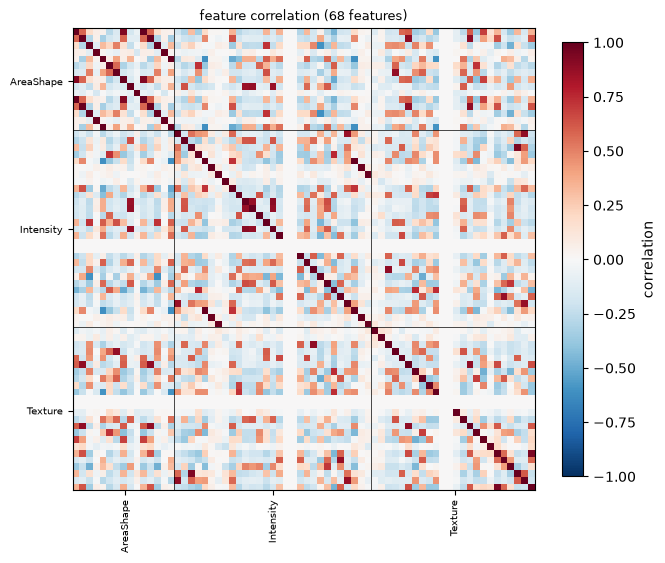

In [7]:
mt.pl.feature_correlation(wells, key=None)
plt.show()

## The operations

Each operation tests one criterion, and `feature_select` combines them. It does not drop
anything: it writes a boolean column to `var`, and only `subset_features` changes the shape,
so you can inspect what would be removed first.

| operation | drops a feature when |
| --- | --- |
| `drop_degenerate` | `normalize` could not scale it and flagged it in `var["degenerate_scale"]` |
| `variance_threshold` | its variance is below `min_variance` |
| `frequency_threshold` | one value dominates it, or it takes very few distinct values |
| `correlation_threshold` | it is highly correlated with another feature |
| `drop_na_columns` | too much of it is missing |
| `blocklist` | it is on the CellProfiler blocklist of known-unreliable features |
| `drop_outliers` | its magnitude has blown up |
| `noise_removal` | it varies too much between replicates of the same perturbation |

Two of these are easy to get wrong.

`variance_threshold` is a plain variance cut. The frequency-and-uniqueness rule often
described under that name is a separate operation, `frequency_threshold`, and its two
criteria combine with OR.

`correlation_threshold` uses the signed correlation, not the absolute value, so two
features correlated at −1.0 are both kept. pycytominer does the same, and mantispy matches
it.

In [8]:
for operation in ("variance_threshold", "correlation_threshold", "blocklist", "drop_na_columns"):
    trial = wells.copy()
    mt.pp.feature_select(trial, operations=(operation,))
    print(f"{operation:24s} keeps {int(trial.var['selected'].sum()):3d} of {trial.n_vars}")

variance_threshold       keeps  64 of 68
correlation_threshold    keeps  56 of 68
blocklist                keeps  68 of 68
drop_na_columns          keeps  68 of 68


`blocklist` and `drop_na_columns` keep everything here. The blocklist names real CellProfiler
features, and these synthetic ones are not on it. This generator call also injected no missing
values. On a real plate both remove features.

## Running the default pipeline

The default runs five of the eight operations: `drop_degenerate`, which runs first, and
pycytominer's own default of four. `frequency_threshold` and `drop_outliers` are off because
both can remove an informative feature on a screen with few conditions.
`noise_removal` is off because it needs replicate structure, which not every object has.

In [9]:
mt.pp.feature_select(wells)
wells.uns["mantispy"]["feature_select"]

{'drop_degenerate': 4,
 'variance_threshold': 0,
 'correlation_threshold': 12,
 'drop_na_columns': 0,
 'blocklist': 0}

In [10]:
survivors = set(wells.var_names[wells.var["selected"]])
constant = wells.uns["mantispy"]["truth"]["constant_features"]
pairs = wells.uns["mantispy"]["truth"]["correlated_pairs"]

{
    "constant features kept": [name for name in constant if name in survivors],
    "duplicate pairs left intact": [(a, b) for a, b in pairs if {a, b} <= survivors],
}

{'constant features kept': [], 'duplicate pairs left intact': []}

Every constant feature is gone, and no near-duplicate pair survived intact.

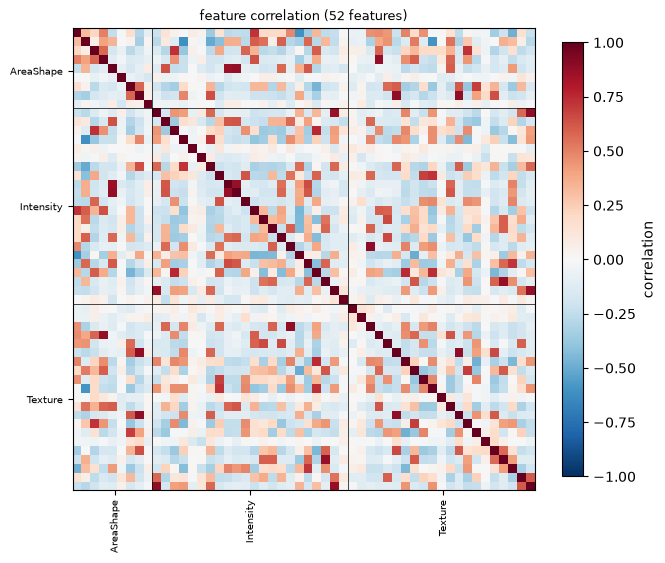

In [11]:
selected = mt.pp.subset_features(wells)
mt.pl.feature_correlation(selected, key=None)
plt.show()

The injected pairs are gone; the darkest cells left are pairs just under the correlation cutoff.
`pl.feature_groups` shows which feature families lost features to selection.

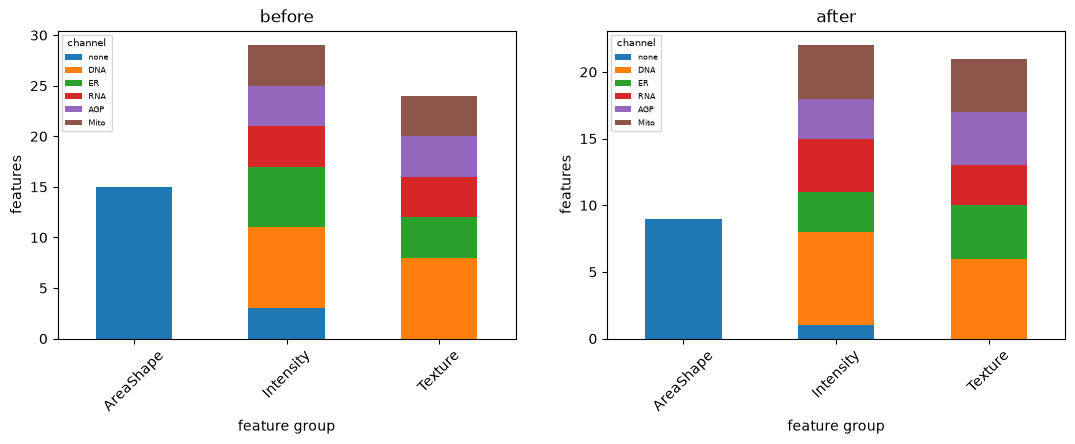

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
mt.pl.feature_groups(wells, ax=axes[0])
axes[0].set_title("before")
mt.pl.feature_groups(wells, key="selected", ax=axes[1])
axes[1].set_title("after")
plt.show()

### The blocklist

The default blocklist is pycytominer's, copied unchanged with its source recorded in the
file. It lists features known to be unreliable: twenty Manders and twenty rank-weighted
colocalization coefficients, plus the three highest nuclear granularity bands in each channel.
`MeasureColocalization` writes Manders, RWC and Costes coefficients, and only the first two
are on the list.

In [13]:
from mantispy._core.features import load_blocklist

blocked = load_blocklist()
len(blocked), blocked[:3]

(55,
 ['Nuclei_Correlation_Manders_AGP_DNA',
  'Nuclei_Correlation_Manders_AGP_ER',
  'Nuclei_Correlation_Manders_AGP_Mito'])

## Looking at the plate

Plate layout artifacts are easiest to see on a plate map.

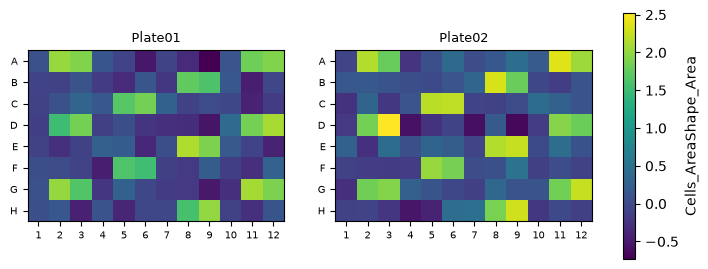

In [14]:
mt.pl.plate(wells, color=wells.var_names[0])
plt.show()

`pl.plate` draws any feature or `obs` column, so it also maps per-well flags, for example
`mt.pl.plate(wells, color="qc_well_pass")`.

## Handing off

`get.to_dataframe` returns the flat, metadata-first table that pycytominer {cite:p}`Serrano_2025`,
cytominer-eval and most published scripts expect.

In [15]:
frame = mt.get.to_dataframe(wells)
frame.iloc[:3, :6]

,Metadata_Plate,Metadata_Well,Metadata_CellCount,Metadata_Row,Metadata_Col,Metadata_Perturbation
0,Plate01,A01,30,0,0,DMSO
1,Plate01,A02,30,0,1,pert00
2,Plate01,A03,30,0,2,pert01


Next: [Plate artifacts and corrections](artifacts.ipynb).